In [1]:
%autosave 60

Autosaving every 60 seconds


____
### еще больше интересного в моём __telegram канале__: https://t.me/ml_maxim
_____
![fishy](../../../../../../Desktop/sticker.webp)
____

## проверки для ffmpeg
он нужен чтобы сделать анимацию

In [2]:
import matplotlib
matplotlib.rcParams['animation.writer'] = 'ffmpeg'
matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'  # тут должен быть ваш путь до ffmpeg

In [3]:
import matplotlib.animation as manimation
assert 'ffmpeg' in manimation.writers.list(), 'проверьте корректность установки ffmpeg'

# main

In [4]:
import matplotlib.pyplot as plt
import mplcyberpunk

In [5]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import roc_auc_score
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython import display
import matplotlib.pyplot as plt

In [6]:
# Задаем параметры для будущих графиков
plt.style.use('fivethirtyeight')

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams.update({'font.size': 18})

# Задаем параметры для будущих графиков
plt.style.use("cyberpunk")

In [7]:
target = np.hstack([np.zeros(80_000), np.ones(20_000)])
np.random.shuffle(target)

## animation

In [8]:
N_ITERATIONS = 200  # число итераций в вашей анимации

In [9]:
aucs = []
randoms_range = np.linspace(7, 0.01, N_ITERATIONS)

In [10]:
Figure, ax = plt.subplots(figsize=(15, 8))

title = ax.text(0.5, 0.25, "", transform=ax.transAxes, ha="center")

lines_plotted = plt.plot([])
line_plotted = lines_plotted[0]

plt.xlim(0, 100_000)
plt.ylim(0, 100)

y = uniform_filter1d(target, size=5_000)
x = np.arange(0, target.shape[0])

plt.hlines(100 * np.mean(target), 0, target.shape[0], color='red', linestyles=':', label='средний таргет\nв датасете')
plt.legend()

plt.ylabel('% содержания целевого события \nв окрестности')
plt.xlabel('порядковый номер строчки данных\n(отранжирован по скору)')
plt.title('Рост качества модели классификации')

plt.xticks(np.arange(0, target.shape[0]+1, 10_000))

plt.tight_layout(pad=3)
plt.close()

In [11]:
def AnimationFunction(frame_idx):

    model = LogisticRegression(random_state=1)
    print(frame_idx, end=', ')
    X = (target + np.random.normal(0, randoms_range[frame_idx], target.shape[0])).reshape(-1, 1)

    model = model.fit(X, target)
    preds = model.predict_proba(X)[:, 1]

    score = roc_auc_score(target, preds)
    y = 100 * uniform_filter1d(target[np.argsort(preds)[::-1]], size=5_000)

    line_plotted.set_data((x, y))
    title.set_text(f'roc auc : {score:0.4f}')

    plt.tight_layout(pad=3)

In [12]:
anim_created = FuncAnimation(Figure, AnimationFunction, frames=N_ITERATIONS)

In [13]:
video = anim_created.to_html5_video()
html = display.HTML(video)
display.display(html)

plt.close()

0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 

## two classifiers comparison
сравним две модели разного качества

In [14]:
X_1 = (target + np.random.normal(0, 2, target.shape[0])).reshape(-1, 1)
X_2 = (target + np.random.normal(0, 0.5, target.shape[0])).reshape(-1, 1)

model_1 = LogisticRegression(random_state=1).fit(X_1, target)
model_2 = LogisticRegression(random_state=1).fit(X_2, target)

preds_1 = model_1.predict_proba(X_1)[:, 1]
preds_2 = model_2.predict_proba(X_2)[:, 1]

score_1 = roc_auc_score(target, preds_1)
score_2 = roc_auc_score(target, preds_2)

y_1 = 100 * uniform_filter1d(target[np.argsort(preds_1)[::-1]], size=5_000)
y_2 = 100 * uniform_filter1d(target[np.argsort(preds_2)[::-1]], size=5_000)

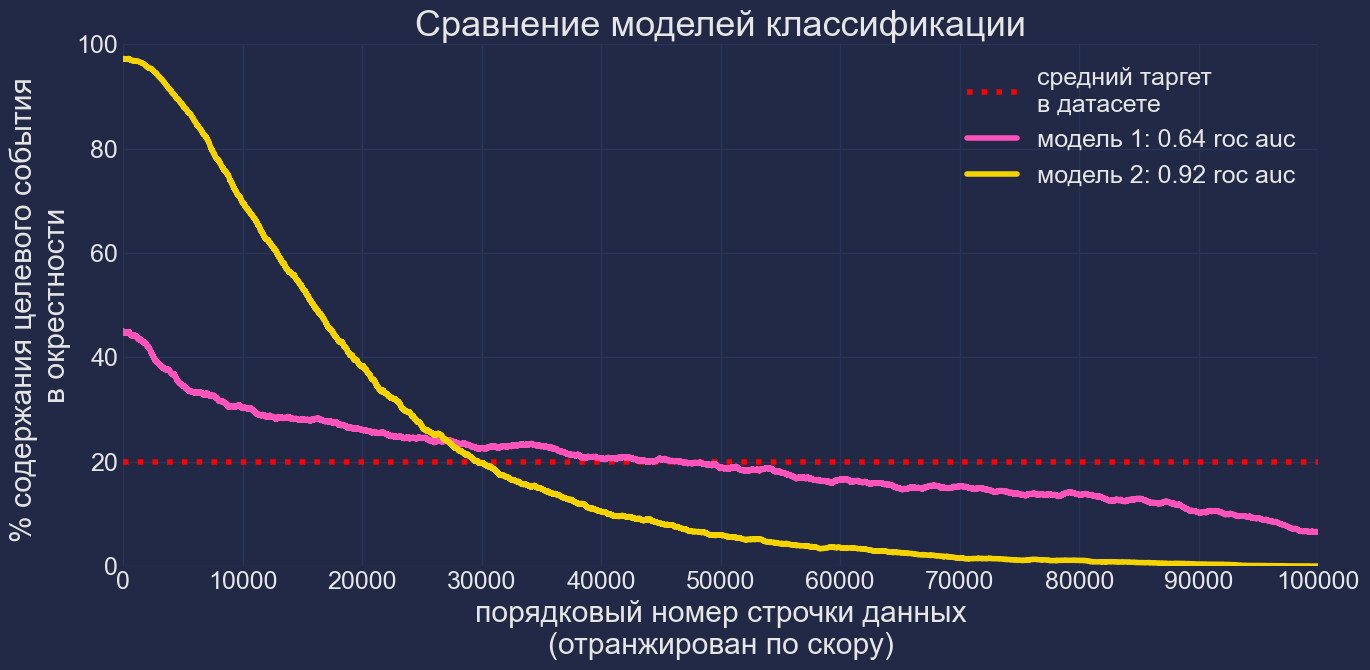

In [15]:
Figure, ax = plt.subplots(figsize=(15, 8))

title = ax.text(0.5, 0.25, "", transform=ax.transAxes, ha="center")

lines_plotted = plt.plot([])
line_plotted = lines_plotted[0]

plt.xlim(0, 100_000)
plt.ylim(0, 100)

y = uniform_filter1d(target, size=5_000)
x = np.arange(0, target.shape[0])

plt.hlines(100 * np.mean(target), 0, target.shape[0], color='red', linestyles=':', label='средний таргет\nв датасете')

plt.plot(x, y_1, label=f'модель 1: {score_1:0.2f} roc auc')
plt.plot(x, y_2, label=f'модель 2: {score_2:0.2f} roc auc')

plt.legend()

plt.ylabel('% содержания целевого события \nв окрестности')
plt.xlabel('порядковый номер строчки данных\n(отранжирован по скору)')
plt.title('Сравнение моделей классификации')

plt.xticks(np.arange(0, target.shape[0]+1, 10_000))

plt.tight_layout(pad=3)
plt.savefig(f'../two_models_comparison.png', dpi=100, bbox_inches='tight')

In [16]:
print('well done')

well done
